In [1]:
import os
import pandas as pd
import plotnine as pln

# helper functions

In [2]:
def annotation_df(res, target, x=0.41, y=0.65):
    corr_data = []
    for source in ["viral", "cellular"]:
        for split in ["Pooled Split", "Site Split"]:
            q = '(Source == @source) & (Split == @split)' 
            corr = res.query(q)['R2_score_test'].corr(res.query(q)[target], method='pearson')
            
            corr_data.append({
                'Source': source,
                'Split': split,
                'correlation': corr,
                'label': f"r = {corr:.03f}"
            })

    ann_df = pd.DataFrame(corr_data)
    ann_df[target] = x
    ann_df['R2_score_test'] = ann_df['Source'].map({'cellular': y, 'viral': y+0.05,})
    return ann_df

# Results

In [3]:
lassocv = pd.read_csv('../experiments/compiled_results/res_lassoCV_esm2_650m_variability_metrics.csv', index_col=0)

p = ["Pooled Split"]
s = ["Site Split"]
a = ["Pooled Split", "Site Split"]

res = lassocv.query('Split in @p').copy()
res['Source'] = pd.Categorical(res['Source'], categories=['viral', 'cellular'])
res

,Model,Source,Dataset,Split,R2_score_train,MAE_score_train,RMSE_score_train,rho_score_train,R2_score_test,MAE_score_test,...,rho_score_test,num_nonzero_coefs,prot_length,cv,RVSM,coverage,coverage_site,coverage_within,fractionSD,fractionSD_ranked
296,ESM-2 650M,cellular,AMIE_PSEAE_Whitehead,Pooled Split,0.593274,0.473718,0.637422,0.794904,0.486188,0.525113,...,0.738094,444.8,346,0.895529,0.684369,0.949133,0.985549,0.963050,0.504399,0.489736
298,ESM-2 650M,cellular,B3VI55_LIPSTSTABLE,Pooled Split,0.556010,0.529118,0.665334,0.764524,0.468531,0.579832,...,0.713379,590.4,439,0.626518,0.596003,0.948633,1.000000,0.948633,0.660592,0.751708
300,ESM-2 650M,cellular,B3VI55_LIPST_Whitehead2015,Pooled Split,0.360828,0.607812,0.800282,0.562654,0.256701,0.650875,...,0.474479,533.0,439,0.542289,0.513957,0.918793,1.000000,0.918793,0.749431,0.890661
302,ESM-2 650M,cellular,BG_STRSQ_hmmerbit,Pooled Split,0.609863,0.466085,0.623503,0.752856,0.427510,0.557889,...,0.657100,357.2,501,0.837254,0.600783,0.349301,1.000000,0.349301,0.526946,0.728543
304,ESM-2 650M,cellular,BLAT_ECOLX_Ostermeier2014,Pooled Split,0.721392,0.415068,0.527552,0.862508,0.666155,0.453597,...,0.834210,414.2,286,0.551118,0.745130,0.955944,1.000000,0.955944,0.412587,0.391608
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
434,ESM-2 650M,viral,SARS2_PLPRO_activity_Wu,Pooled Split,0.568696,0.542237,0.657851,0.738479,0.476946,0.587562,...,0.670703,357.8,316,0.341990,0.817721,0.844146,0.996835,0.846825,0.295238,0.282540
436,ESM-2 650M,viral,SARS2_PRD0038_RBD_Starr,Pooled Split,0.585161,0.467548,0.644816,0.616855,0.470560,0.509222,...,0.561168,261.4,200,0.878247,0.806632,0.999500,1.000000,0.999500,0.300000,0.495000
438,ESM-2 650M,viral,SARS2_RBD_binding_Starr,Pooled Split,0.675776,0.409628,0.565875,0.702333,0.578545,0.475782,...,0.650842,436.8,1273,0.605886,0.828026,0.149332,0.157895,0.945771,0.263682,0.164179
440,ESM-2 650M,viral,SARS2_RBD_expression_Starr,Pooled Split,0.729695,0.409088,0.520078,0.843533,0.574433,0.506460,...,0.751288,562.6,1273,0.455119,0.857385,0.149175,0.157895,0.944776,0.194030,0.169154


In [28]:
#res.query('RVSM > 0.7')['Dataset'].unique()

# Variation across site

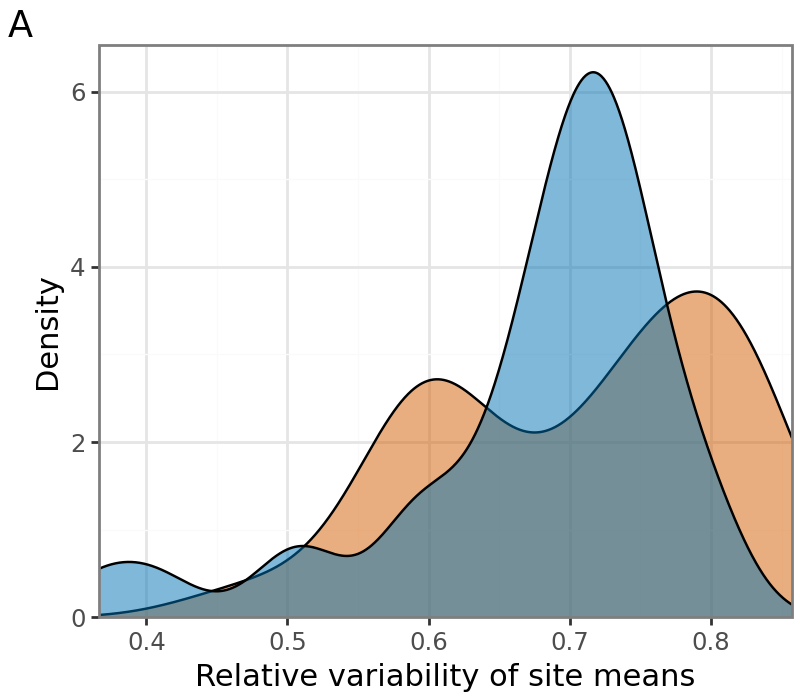

In [4]:
p1 = (
    pln.ggplot(res, pln.aes(x='RVSM', fill='Source'))
    + pln.scale_fill_manual(values={"viral": "#D55E00", "cellular": "#0072B2"})
    + pln.geom_density(alpha=0.5)
    + pln.scale_y_continuous(expand = (0, 0, 0.05, 0))
    + pln.scale_x_continuous(expand = (0, 0, 0.0, 0.0))
    + pln.theme_bw()
    + pln.labs(
        x='Relative variability of site means',
        y='Density',
        tag='A')
    + pln.theme(
        legend_position='none',
        figure_size=(4, 3.5))
    )

p1

# Variation within site

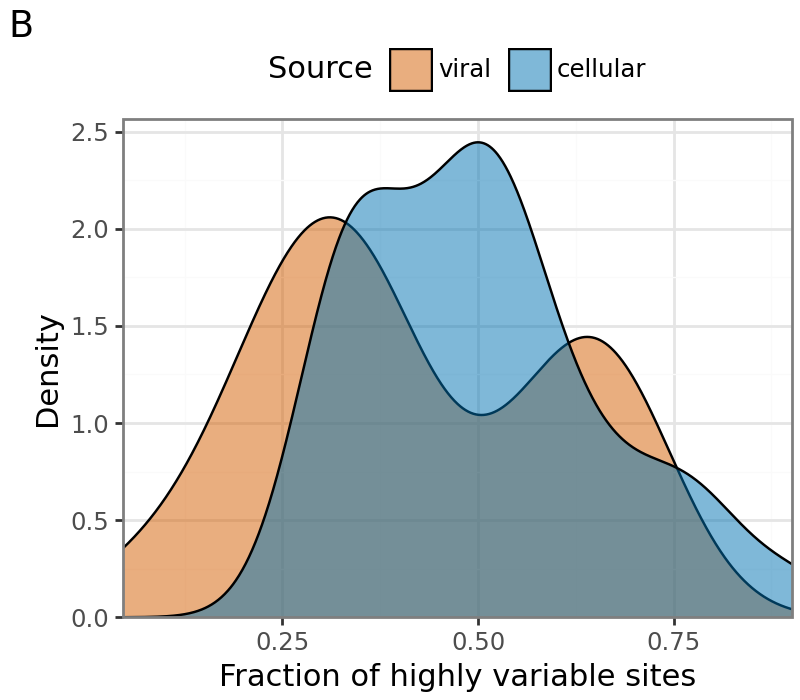

In [6]:
p2 = (
    pln.ggplot(res, pln.aes(x='fractionSD', fill='Source'))
    + pln.scale_fill_manual(values={"viral": "#D55E00", "cellular": "#0072B2"})
    + pln.geom_density(alpha=0.5)
    + pln.scale_y_continuous(expand = (0, 0, 0.05, 0))
    + pln.scale_x_continuous(expand = (0, 0, 0.0, 0.0))
    + pln.theme_bw()
    + pln.labs(
        x='Fraction of highly variable sites',
        y='Density',
        tag='B')
    + pln.theme(
        legend_position='top',
        figure_size=(4, 3.5))
    )

p2

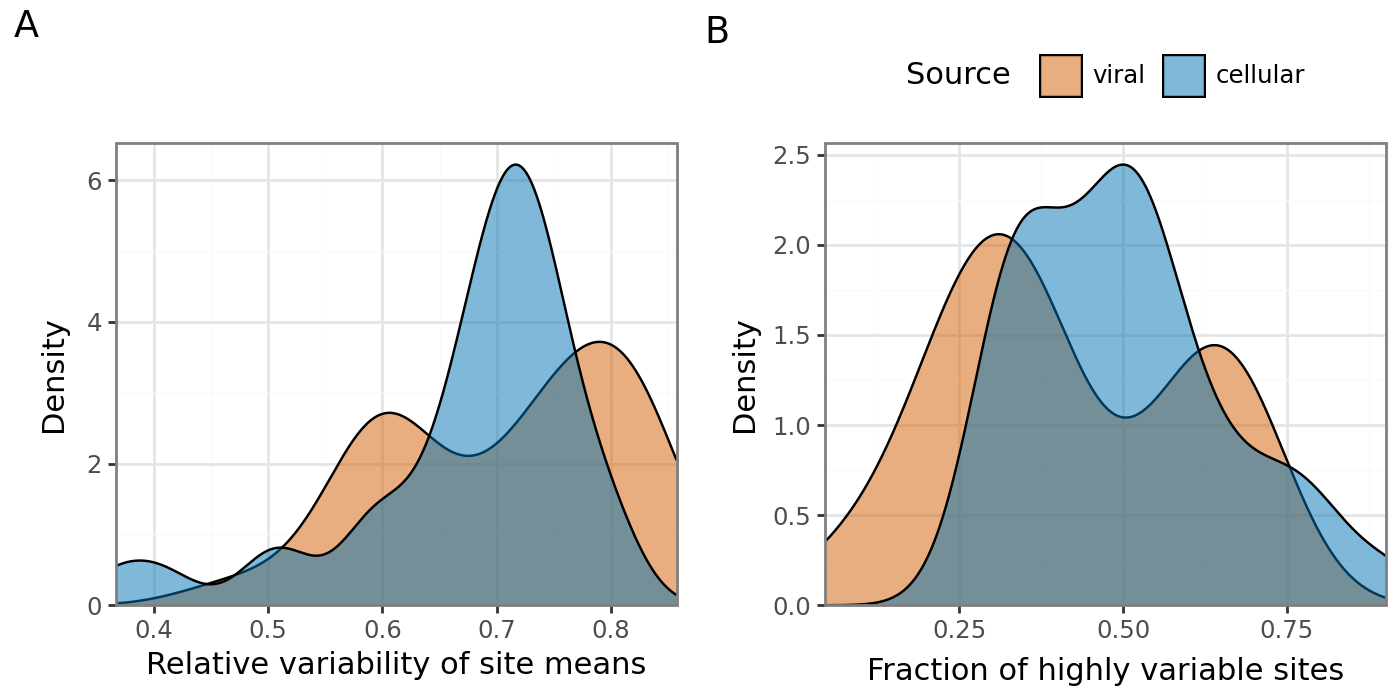

In [19]:
comp = p1 | p2
plot = comp + pln.theme(figure_size=(7, 3.5))
plot.save(filename='../experiments/figures/supp2_site_variation_density.png', dpi=600)
plot

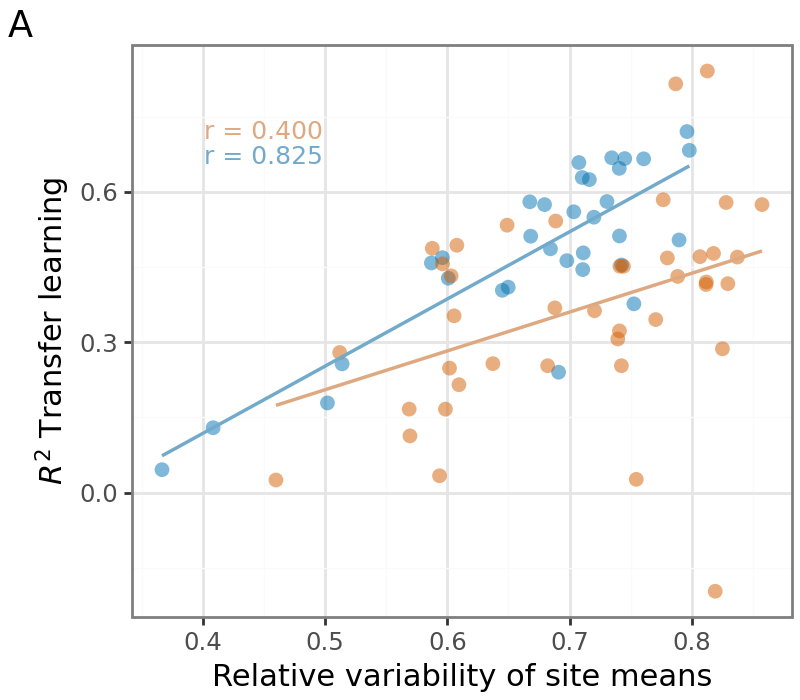

In [9]:
target = 'RVSM'
ann_df = annotation_df(res, target,  x=0.401, y=0.67)
ann_df = ann_df.query('Split == "Pooled Split"')

p3 = (
    pln.ggplot(res, pln.aes(x=target, y='R2_score_test', fill='Source'))
    + pln.scale_fill_manual(values={"viral": "#D55E00", "cellular": "#0072B2"})
    + pln.geom_point(size=3, alpha=0.5, stroke=0)
    + pln.geom_smooth(method='lm', se=False, alpha=1, size=0.7,  mapping=pln.aes(color='Source'))
    + pln.scale_color_manual(values={"viral": "#DEA880", "cellular": "#72AACB"})
    + pln.geom_text(data= ann_df , mapping=pln.aes(x=target, y='R2_score_test', label='label', color='Source'), 
                    size=9, ha="left", inherit_aes=False)
    + pln.theme_bw()
    + pln.theme(legend_position='none', figure_size=(4, 3.5))
    + pln.labs(
        y='$R^2$ Transfer learning',
        x= 'Relative variability of site means',
        tag='A')
    )

p3

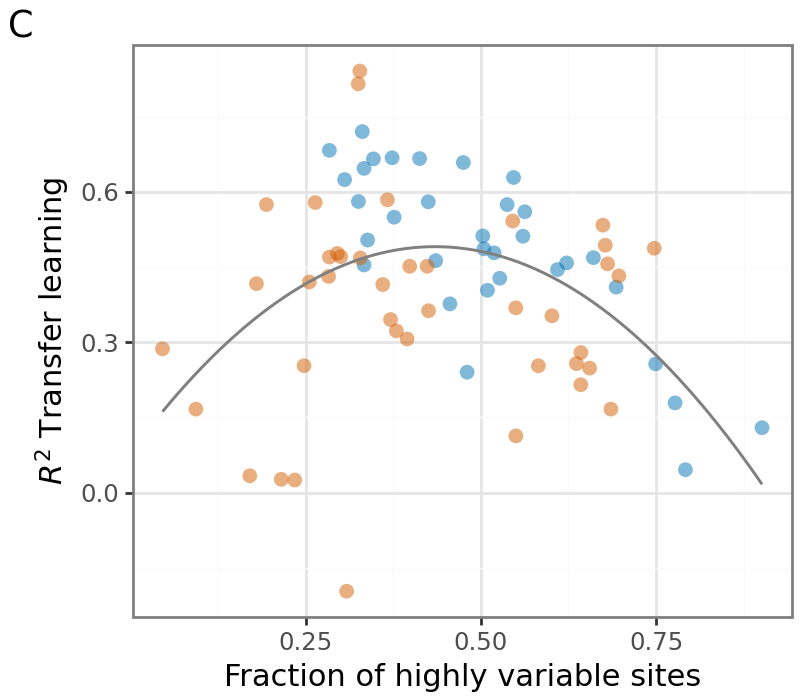

In [10]:
p5 = (
    pln.ggplot(res, pln.aes(x='fractionSD', y='R2_score_test'))
    + pln.scale_fill_manual(values={"viral": "#D55E00", "cellular": "#0072B2"})
    + pln.geom_point(size=3, alpha=0.5, stroke=0, mapping=pln.aes(fill='Source'))
 
    + pln.geom_smooth(
        method='lm',
        formula='y ~ I(x*x) + x',
        se=False, alpha=1, size=0.6, color='grey'
      )
    + pln.scale_color_manual(values={"viral": "#DEA880", "cellular": "#72AACB"})
    + pln.theme_bw()
    + pln.theme(
        legend_position='none', 
        figure_size=(4, 3.5)
        )
    
    + pln.labs(
        y='$R^2$ Transfer learning',
        x = 'Fraction of highly variable sites',
        tag='C'
      )
    )

p5

# Correlation between variation within and across sites

In [11]:
def annotation_corr(res, x=0.41, y=0.65):
    corr_data = []
    for source in ["viral", "cellular"]:
        for split in ["Pooled Split", "Site Split"]:
            q = '(Source == @source) & (Split == @split)' 
            corr = res.query(q)['RVSM'].corr(res.query(q)['fractionSD'], method='pearson')
            
            corr_data.append({
                'Source': source,
                'Split': split,
                'correlation': corr,
                'label': f"r = {corr:.03f}"
            })

    ann_df = pd.DataFrame(corr_data)
    ann_df['fractionSD'] = x
    ann_df['RVSM'] = ann_df['Source'].map({'cellular': y, 'viral': y+0.05,})
    return ann_df



ann_df = annotation_corr(res, x=0.7, y=0.77)
ann_df = ann_df.query('Split == "Pooled Split"')
ann_df

,Source,Split,correlation,label,fractionSD,RVSM
0,viral,Pooled Split,-0.603715,r = -0.604,0.7,0.82
2,cellular,Pooled Split,-0.878519,r = -0.879,0.7,0.77


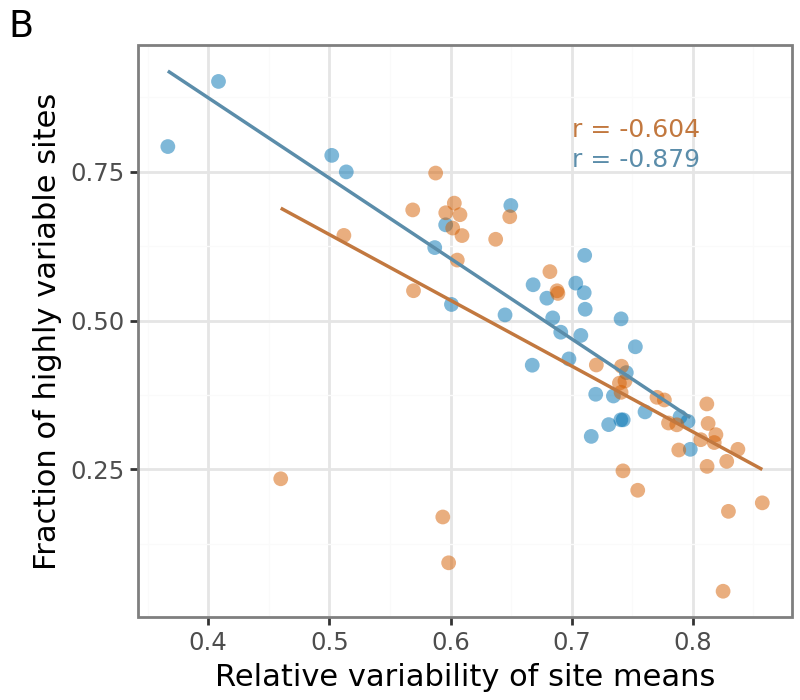

In [13]:
p4 = (
    pln.ggplot(res, pln.aes(x='RVSM', y='fractionSD', fill='Source'))
    + pln.scale_fill_manual(values={"viral": "#D55E00", "cellular": "#0072B2"})
    + pln.geom_point(size=3, alpha=0.5, stroke=0)
    + pln.geom_smooth(method='lm', se=False, alpha=1, size=0.7,  mapping=pln.aes(color='Source'))
    + pln.scale_color_manual(values={"viral": "#C2783F", "cellular": "#5B8DAA"})
    + pln.theme_bw()
    + pln.geom_text(data=ann_df, mapping=pln.aes(x='fractionSD', y='RVSM', label='label', color='Source'), 
                    size=9, ha="left", inherit_aes=False)
    + pln.labs(
        y='Fraction of highly variable sites',
        x='Relative variability of site means',
        tag='B'
        )
    + pln.theme(
        legend_position='none',
        figure_size=(4, 3.5))
        )

p4

# Transfer leanring vs AVG

In [14]:
def read_results(res_dir_path, model_name):
    res = pd.DataFrame()
    for file in os.listdir(res_dir_path):
        if file.endswith('.csv'):
            dataset = file.split('.')[0]
            df = pd.read_csv(os.path.join(res_dir_path, file), index_col=0)
            df['Dataset'] = dataset
            res = pd.concat([res, df], ignore_index=True)
    res['Model'] = model_name
    return res

In [15]:
def load_results(lassoCV_res_dir, AVG_res_dir):
    lassoCV = pd.DataFrame()
    for model in ['esm2_650m']:
        for source in ['viral', 'cellular']:
            for method in ['pool_split']:
                res_dir_path = f'{lassoCV_res_dir}/{model}/{source}/{method}/'
                res = read_results(res_dir_path, 'ESM-2 650M')
                res['Source'] = source
                res['Split'] = method
                res['Model'] = model
                
                lassoCV = pd.concat([lassoCV, res], ignore_index=True)

    res_avg = pd.DataFrame()
    for source in ['viral', 'cellular']:
        for method in ['pool_split']:
            res_dir_path = f'{AVG_res_dir}/{source}/{method}/'
            res = read_results(res_dir_path, 'AVG')
            res['Source'] = source
            res['Split'] = method
            res_avg = pd.concat([res_avg, res], ignore_index=True)


    res = pd.concat([res_avg, lassoCV.drop('num_nonzero_coefs', axis=1)])
    res = res.groupby(['Model', 'Dataset', 'Source', 'Split'], as_index=False).mean()
    res = res.query('Split == "pool_split"')
    rename_map = {
            'esm2_viral_650m_MP15_partial':'esm2_viral_partial', 
            'esm2_viral_650m_MP15':'esm2_viral_full',
            'pool_split':'pooled',
            'site_split':'site',
    }
    res.replace(rename_map, inplace=True)

    res_pivot = pd.pivot_table(res, index=['Dataset', 'Source', 'Split'], columns='Model', values='R2_score_test').reset_index()

    return res_pivot 

/stor/work/Wilke/luiz/ViCAM/venv/lib/python3.10/site-packages/plotnine/layer.py:372: PlotnineWarning: geom_point : Removed 1 rows containing missing values.


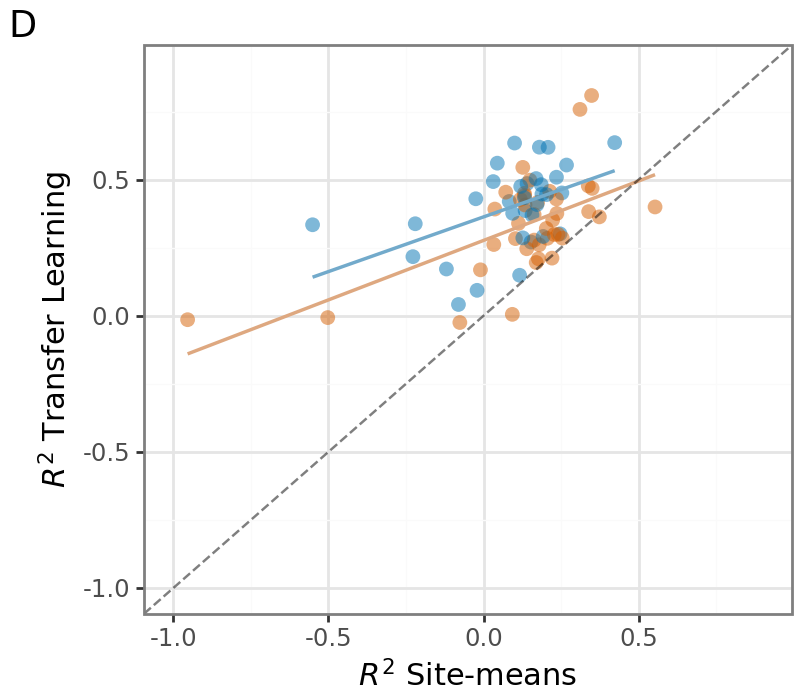

In [16]:
resSTD07 = load_results('../experiments/lassoCV_STD0.7_filtered', '../experiments/AVG_STD0.7_filtered/')
resSTD07['Source'] = pd.Categorical(resSTD07['Source'], categories=['viral', 'cellular'])

p6 = (
    pln.ggplot(resSTD07, pln.aes(y='esm2_650m', x='AVG', fill='Source'))
    + pln.scale_fill_manual(values={"viral": "#D55E00", "cellular": "#0072B2"})
    + pln.geom_point(size=3, alpha=0.5, stroke=0)
    + pln.geom_smooth(method='lm', se=False, alpha=1, size=0.7,  mapping=pln.aes(color='Source'))
    + pln.scale_color_manual(values={"viral": "#DEA880", "cellular": "#72AACB"})
    + pln.theme_bw(11)
    + pln.geom_abline(intercept=0, alpha=0.5, linetype='dashed')
    + pln.theme(
        figure_size=(4,3.5),
        legend_position='none',
        legend_text=pln.element_text(size=11),
        legend_title=pln.element_blank()
    )
    + pln.ylim(-1, 0.9)
    + pln.xlim(-1, 0.9)
    + pln.labs(
        y="$R^2$ Transfer Learning",
        x="$R^2$ Site-means",
        tag='D'
    )
    )
p6

# composition

/stor/work/Wilke/luiz/ViCAM/venv/lib/python3.10/site-packages/plotnine/layer.py:372: PlotnineWarning: geom_point : Removed 1 rows containing missing values.
/stor/work/Wilke/luiz/ViCAM/venv/lib/python3.10/site-packages/plotnine/layer.py:372: PlotnineWarning: geom_point : Removed 1 rows containing missing values.


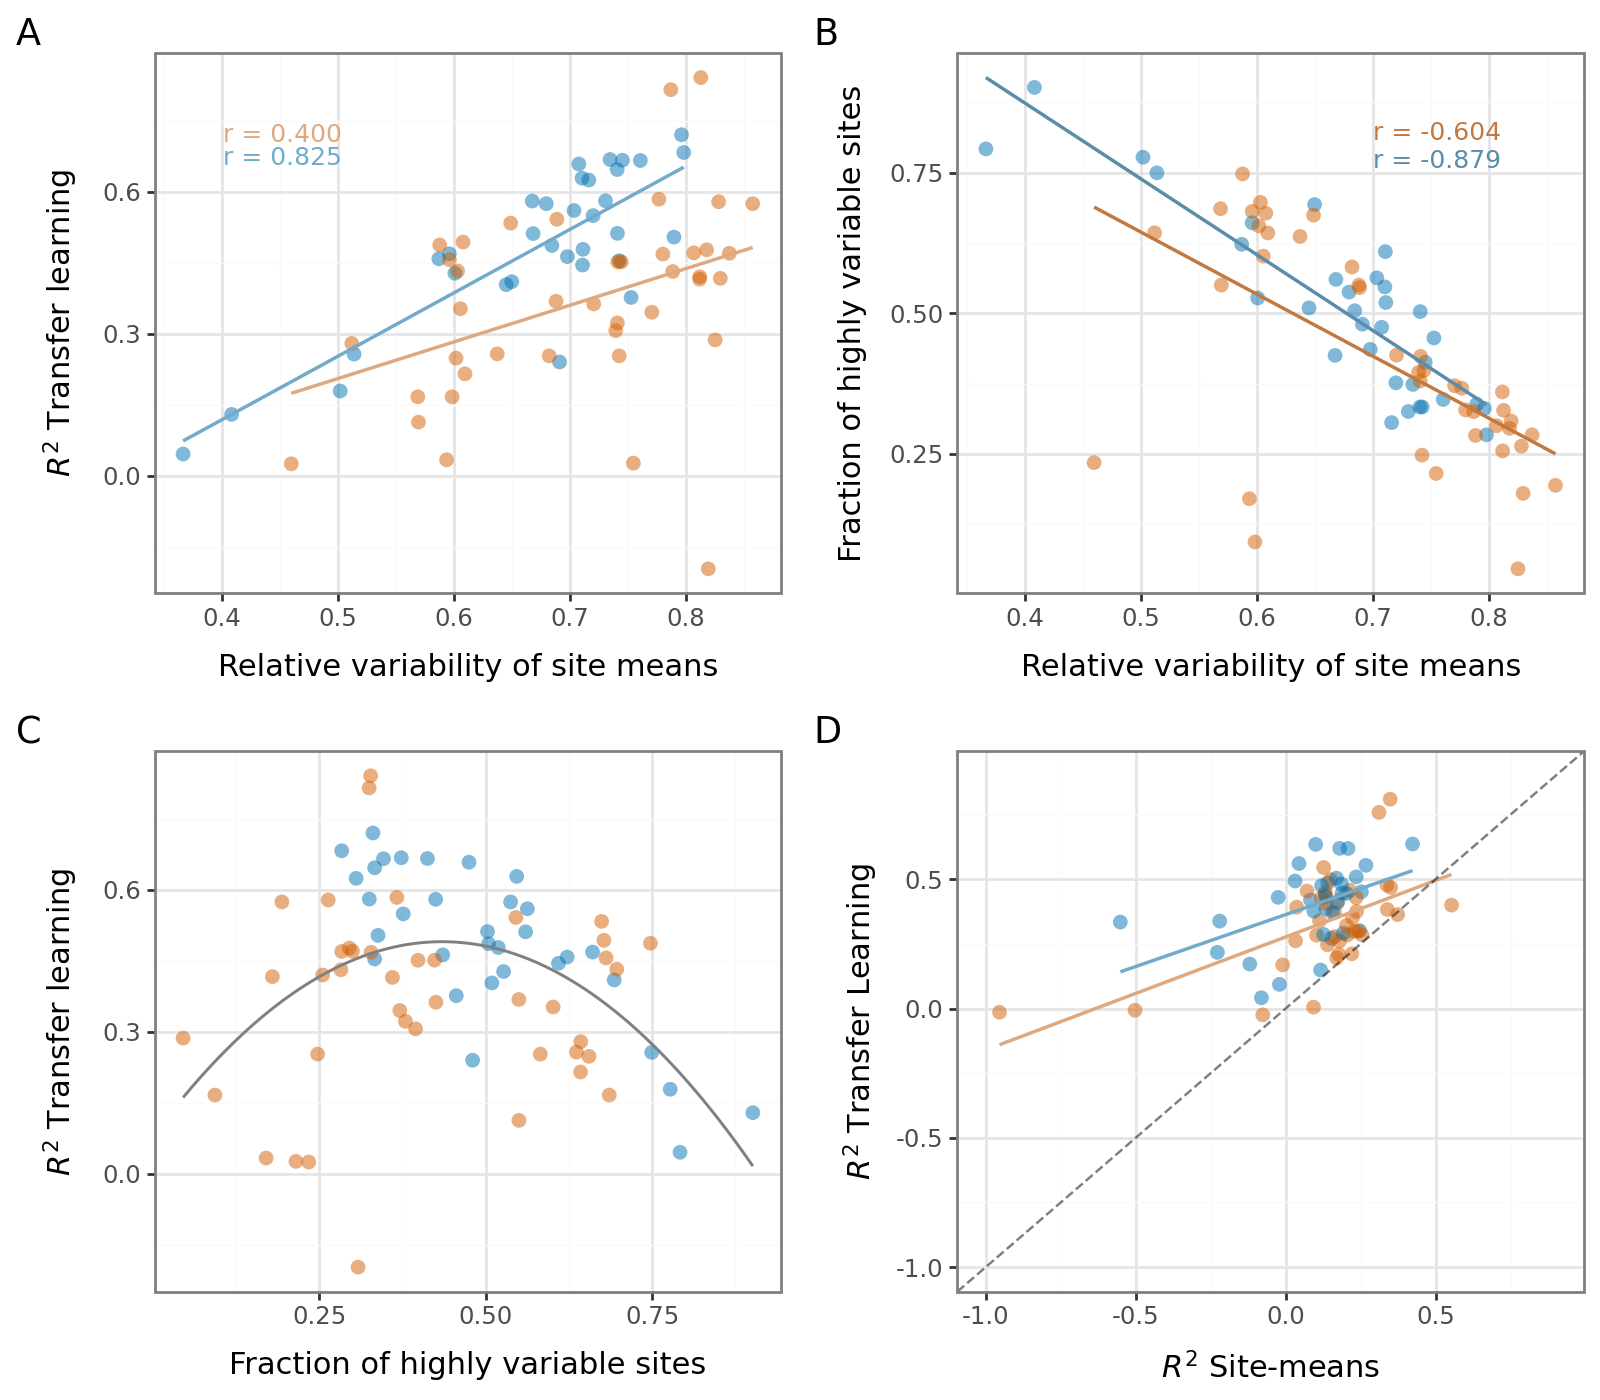

In [18]:
comp = (p3 | p4) / (p5 | p6)
plot = comp + pln.theme(figure_size=(8, 7))
plot.save(filename='../experiments/figures/comp3_site_variation4.png', dpi=600)
plot

# Stratified by Site

In [38]:
lassocv = pd.read_csv('../experiments/compiled_results/res_lassoCV_esm2_650m_variability_metrics.csv', index_col=0)

res = lassocv
res['Source'] = pd.Categorical(res['Source'], categories=['viral', 'cellular'])
res

,Model,Source,Dataset,Split,R2_score_train,MAE_score_train,RMSE_score_train,rho_score_train,R2_score_test,MAE_score_test,...,rho_score_test,num_nonzero_coefs,prot_length,cv,RVSM,coverage,coverage_site,coverage_within,fractionSD,fractionSD_ranked
296,ESM-2 650M,cellular,AMIE_PSEAE_Whitehead,Pooled Split,0.593274,0.473718,0.637422,0.794904,0.486188,0.525113,...,0.738094,444.8,346,0.895529,0.684369,0.949133,0.985549,0.963050,0.504399,0.489736
297,ESM-2 650M,cellular,AMIE_PSEAE_Whitehead,Site Split,0.374695,0.604338,0.795778,0.647042,0.231793,0.647925,...,0.504309,79.6,346,0.895529,0.684369,0.949133,0.985549,0.963050,0.504399,0.489736
298,ESM-2 650M,cellular,B3VI55_LIPSTSTABLE,Pooled Split,0.556010,0.529118,0.665334,0.764524,0.468531,0.579832,...,0.713379,590.4,439,0.626518,0.596003,0.948633,1.000000,0.948633,0.660592,0.751708
299,ESM-2 650M,cellular,B3VI55_LIPSTSTABLE,Site Split,0.362078,0.643427,0.798541,0.642935,0.243568,0.700345,...,0.545077,89.6,439,0.626518,0.596003,0.948633,1.000000,0.948633,0.660592,0.751708
300,ESM-2 650M,cellular,B3VI55_LIPST_Whitehead2015,Pooled Split,0.360828,0.607812,0.800282,0.562654,0.256701,0.650875,...,0.474479,533.0,439,0.542289,0.513957,0.918793,1.000000,0.918793,0.749431,0.890661
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
439,ESM-2 650M,viral,SARS2_RBD_binding_Starr,Site Split,0.238382,0.650661,0.870498,0.389841,0.033222,0.719386,...,0.200680,34.4,1273,0.605886,0.828026,0.149332,0.157895,0.945771,0.263682,0.164179
440,ESM-2 650M,viral,SARS2_RBD_expression_Starr,Pooled Split,0.729695,0.409088,0.520078,0.843533,0.574433,0.506460,...,0.751288,562.6,1273,0.455119,0.857385,0.149175,0.157895,0.944776,0.194030,0.169154
441,ESM-2 650M,viral,SARS2_RBD_expression_Starr,Site Split,0.120889,0.818213,0.930678,0.289695,0.034882,0.875149,...,0.193756,16.4,1273,0.455119,0.857385,0.149175,0.157895,0.944776,0.194030,0.169154
442,ESM-2 650M,viral,SARS2_XBB15_RBD_Taylor,Pooled Split,0.666417,0.440333,0.577750,0.693423,-0.196764,0.541360,...,0.610699,454.0,201,0.678914,0.819106,0.999751,1.000000,0.999751,0.308458,0.363184


In [33]:
def annotation_df(res, target, x=0.41, y=0.65):
    corr_data = []
    for source in ["viral", "cellular"]:
        for split in ["Pooled Split", "Site Split"]:
            q = '(Source == @source) & (Split == @split)' 
            corr = res.query(q)['R2_score_test'].corr(res.query(q)[target], method='pearson')
            
            corr_data.append({
                'Source': source,
                'Split': split,
                'correlation': corr,
                'label': f"r = {corr:.03f}"
            })

    ann_df = pd.DataFrame(corr_data)
    ann_df[target] = x
    ann_df['R2_score_test'] = ann_df['Source'].map({'cellular': y, 'viral': y+0.05,})
    return ann_df

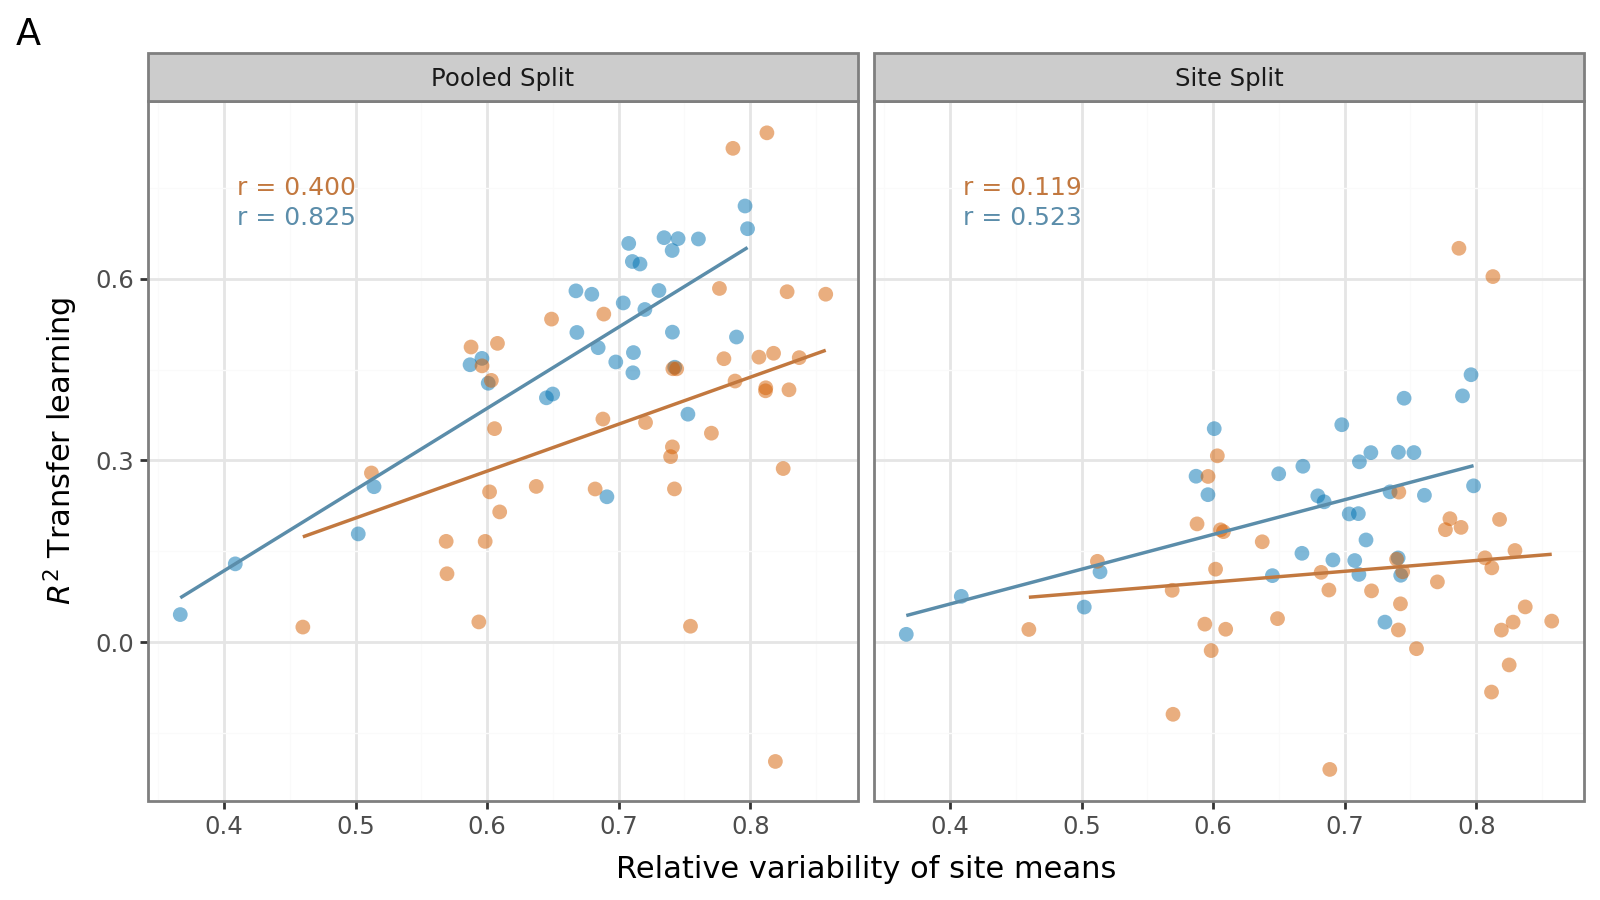

In [34]:
target = 'RVSM'
ann_df = annotation_df(res, target,  y=0.7)

RVSM = (
    pln.ggplot(res, pln.aes(x=target, y='R2_score_test', fill='Source'))
    + pln.scale_fill_manual(values={"viral": "#D55E00", "cellular": "#0072B2"})
    + pln.facet_grid('~Split')
    + pln.geom_point(size=3, alpha=0.5, stroke=0)
    + pln.geom_smooth(method='lm', se=False, alpha=1, size=0.7,  mapping=pln.aes(color='Source'))
    + pln.scale_color_manual(values={"viral": "#C2783F", "cellular": "#5B8DAA"})
    + pln.geom_text(data=ann_df, mapping=pln.aes(x=target, y='R2_score_test', label='label', color='Source'), 
                    size=9, ha="left", inherit_aes=False)
    + pln.theme_bw()
    + pln.theme(legend_position='none', figure_size=(8, 4.5))
    + pln.labs(
         y='$R^2$ Transfer learning',
        x= 'Relative variability of site means',
        tag='A')
    )
RVSM

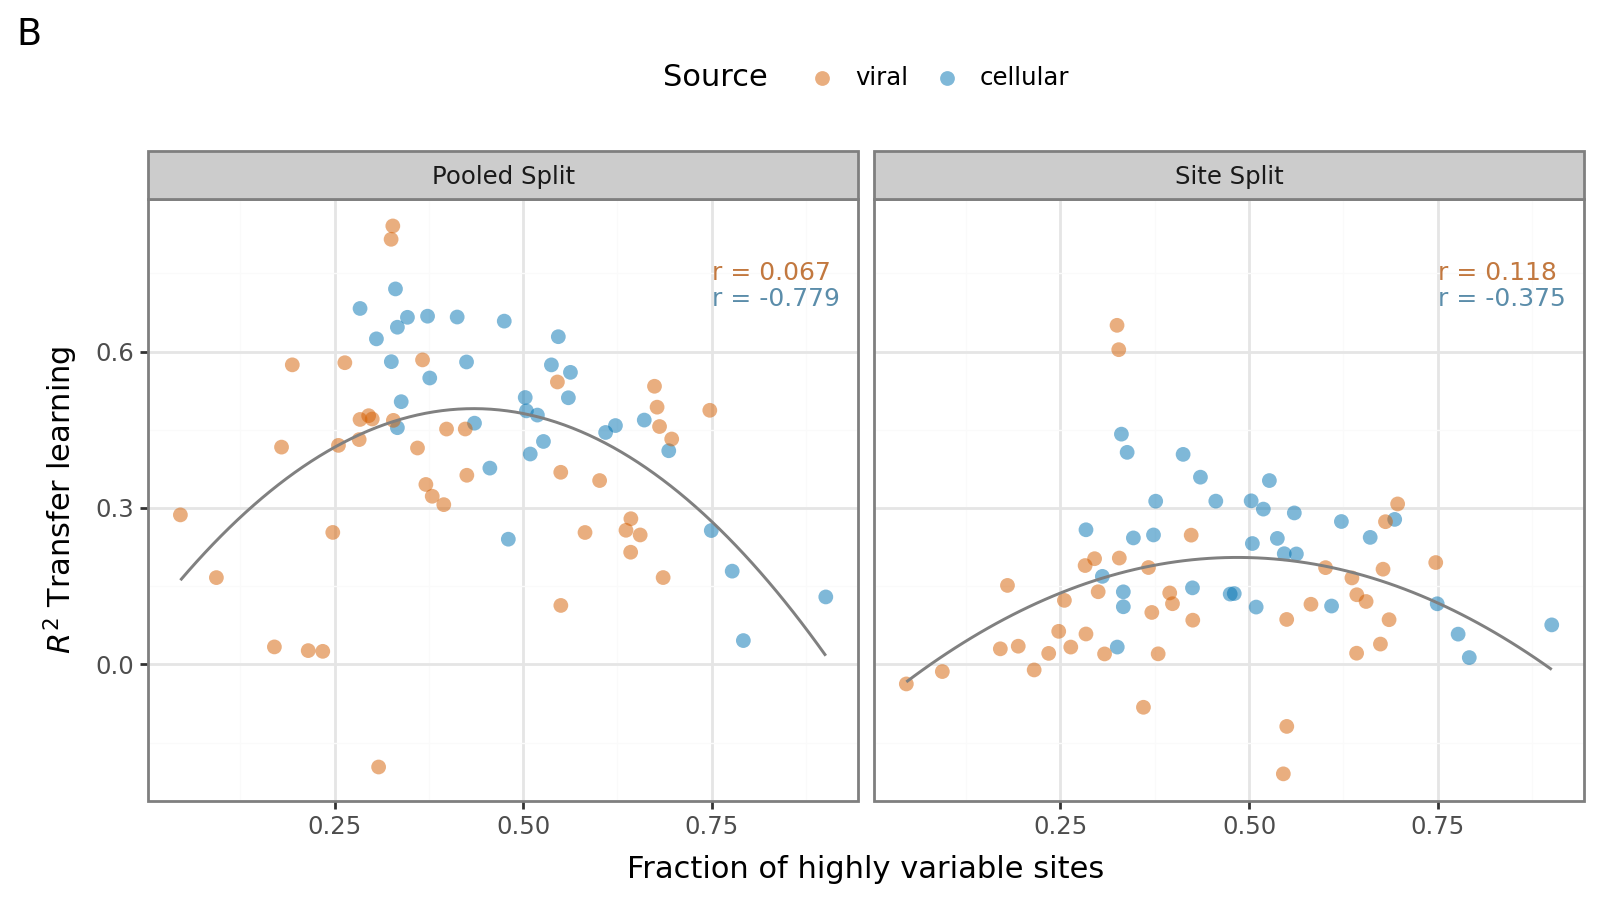

In [ ]:
target = 'fractionSD'
ann_df = annotation_df(res, target, x=0.75, y=0.7)

FHVS = (
    pln.ggplot(res, pln.aes(x=target, y='R2_score_test'))
    + pln.geom_point(size=3, alpha=0.5, stroke=0, mapping=pln.aes(fill='Source'))
    + pln.scale_fill_manual(values={"viral": "#D55E00", "cellular": "#0072B2"})
    + pln.facet_grid('~Split')

    + pln.geom_smooth(
        method='lm',
        formula='y ~ I(x*x) + x',
        se=False, alpha=1, size=0.6, color='grey'
      )

    + pln.scale_color_manual(values={"viral": "#C2783F", "cellular": "#5B8DAA"})
    
    + pln.geom_text(data=ann_df, mapping=pln.aes(x=target, y='R2_score_test', label='label', color='Source'), 
                size=9, ha="left", inherit_aes=False, show_legend=False)

    + pln.theme_bw()
    + pln.theme(legend_position='top', figure_size=(8, 4.5))
    + pln.labs(
        y='$R^2$ Transfer learning',
        x= 'Fraction of highly variable sites',
        tag='B')
    )

FHVS

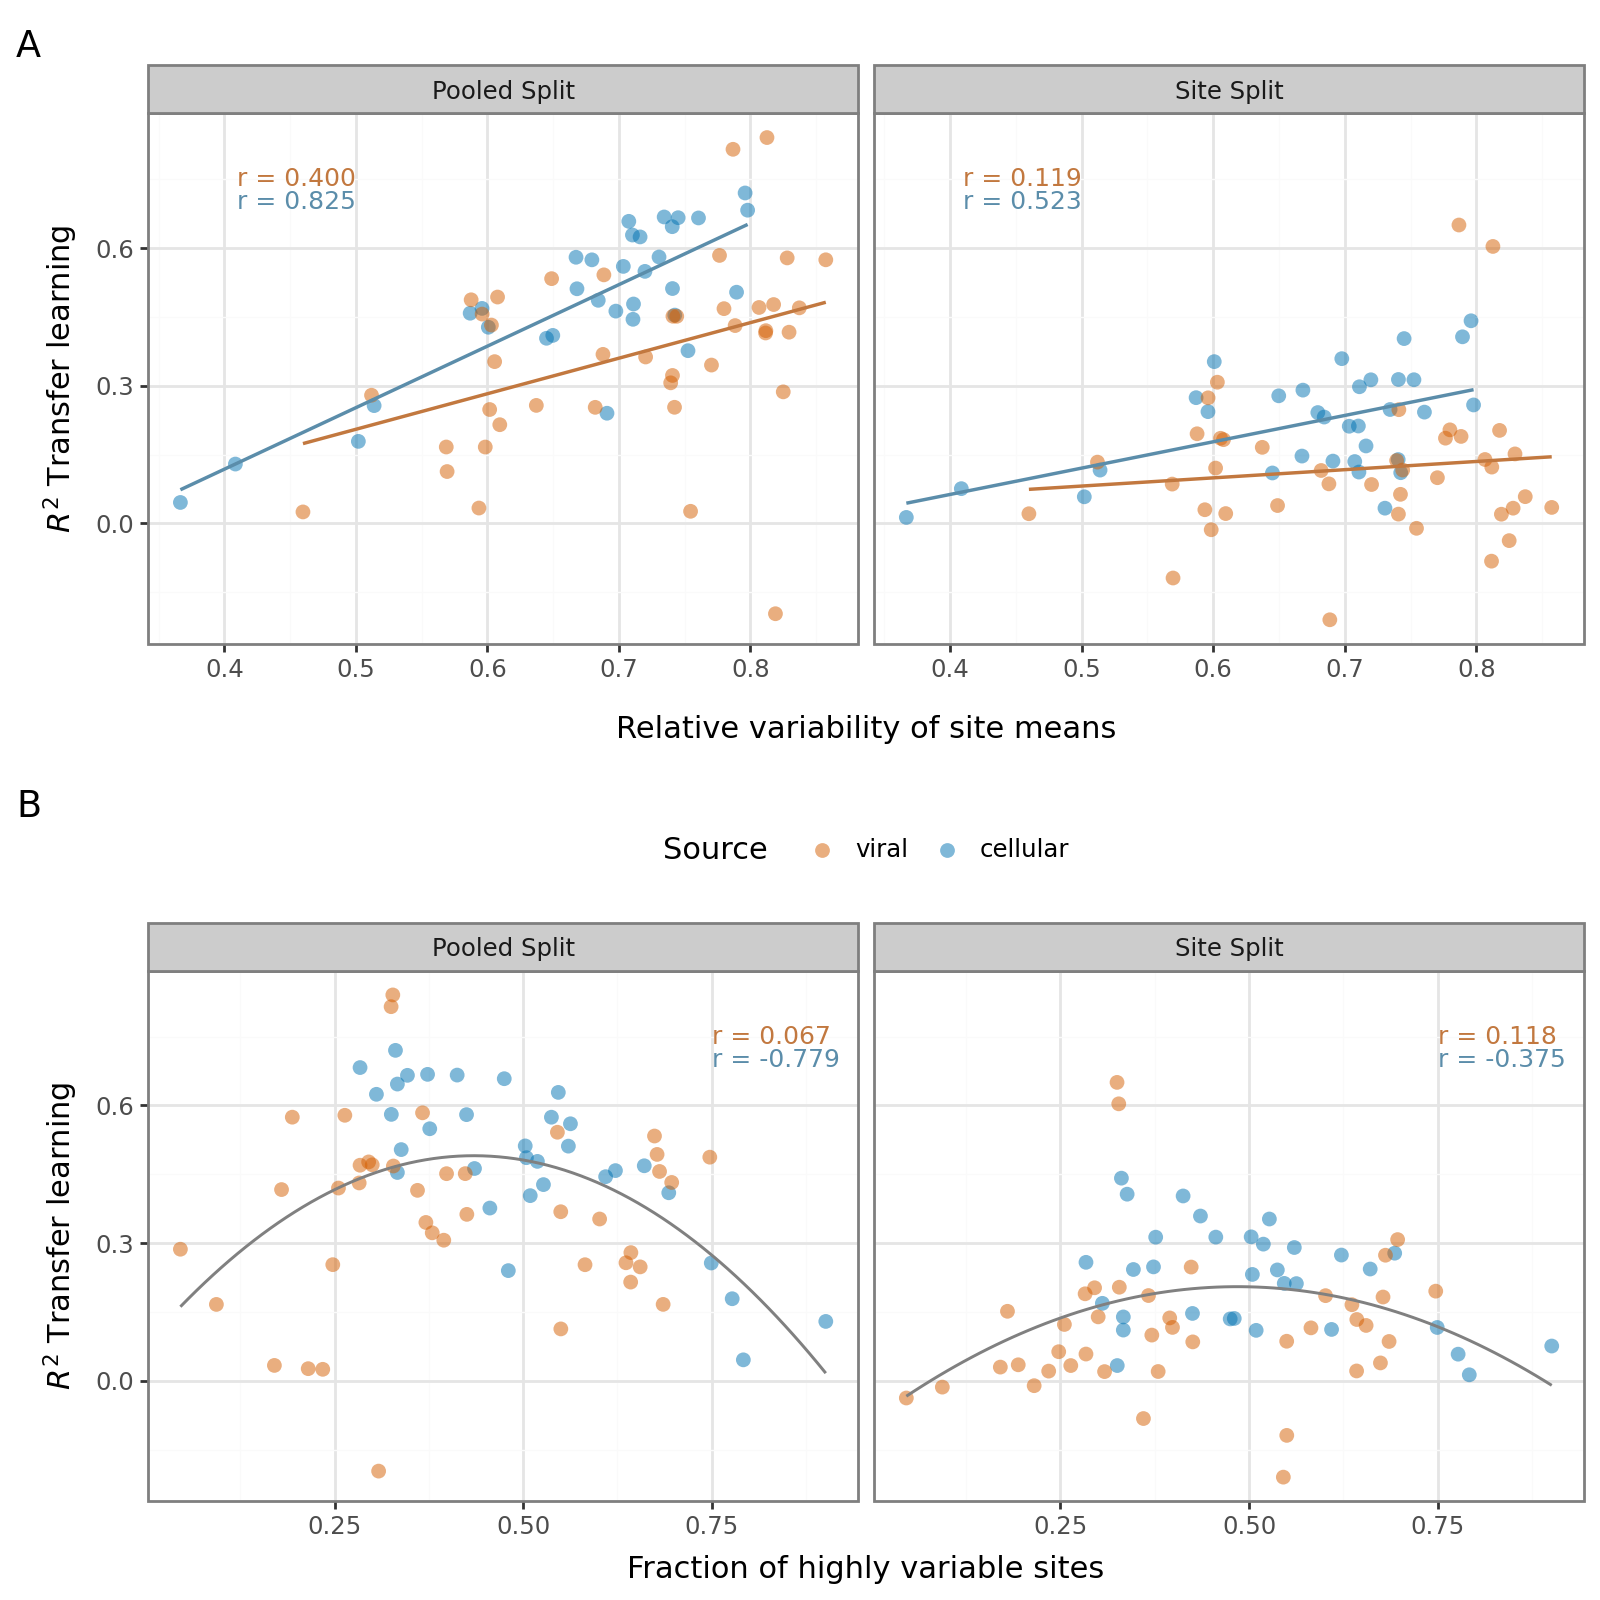

In [42]:
comp = RVSM / FHVS
plot = comp + pln.theme(figure_size=(8, 8))
plot.save(filename='../experiments/figures/supp_var_metrics_Site_Split.png', dpi=600)
plot